In [1]:
from cobra.io import read_sbml_model
from copy import deepcopy
from cobra.flux_analysis import pfba
import pandas as pd

model = read_sbml_model("./data/iMM904.xml")

In [3]:
print("=== Model summary ===")
print("Reactions:", len(model.reactions))
print("Metabolites:", len(model.metabolites))
print("Genes:", len(model.genes))
print("Objective:", model.objective.expression)
print()

# =========================
# 2. 查看默认培养基
# =========================
print("=== Default medium (allowed uptake) ===")
for rxn in model.exchanges:
    if rxn.lower_bound < 0:
        print(f"{rxn.id:20s} {rxn.lower_bound:12.4f}   {rxn.name}")
print()

print("=== model.medium ===")
print(model.medium)
print()

# =========================
# 3. 列出所有 exchange reactions
# =========================
print("=== All exchange reactions ===")
for rxn in model.exchanges:
    print(f"{rxn.id:20s} {rxn.name}")
print()

# =========================
# 4. 搜索关键 exchange IDs
# =========================
print("=== Search possible maltose exchange IDs ===")
for rxn in model.exchanges:
    text = (rxn.id + " " + rxn.name).lower()
    if "malt" in text:
        print(f"{rxn.id:20s} {rxn.name}")
print()

print("=== Search possible starch/dextrin exchange IDs ===")
for rxn in model.exchanges:
    text = (rxn.id + " " + rxn.name).lower()
    if "starch" in text or "dextrin" in text or "amylase" in text:
        print(f"{rxn.id:20s} {rxn.name}")
print()

print("=== Search key exchange IDs ===")
keywords = [
    "glc", "glucose", "malt", "starch", "dextrin", "o2", "oxygen",
    "nh4", "ammon", "pi", "phosphate", "so4", "sulfate",
    "etoh", "ethanol", "glyc", "glycerol", "ac", "acetate"
]
for rxn in model.exchanges:
    text = (rxn.id + " " + rxn.name).lower()
    if any(k in text for k in keywords):
        print(f"{rxn.id:20s} {rxn.name}")
print()

# =========================
# 5. 设置最小培养基
# =========================
def set_minimal_medium(model, carbon_source_id, carbon_uptake=10.0, oxygen_uptake=20.0):
    """
    构建标准最小培养基：
    - 关闭所有摄取
    - 只打开一个碳源 + 必要无机盐/离子
    """
    medium = {rxn.id: 0.0 for rxn in model.exchanges}

    candidate_medium = {
        carbon_source_id: carbon_uptake,
        "EX_o2_e": oxygen_uptake,
        "EX_nh4_e": 10.0,
        "EX_pi_e": 10.0,
        "EX_so4_e": 10.0,
        "EX_h2o_e": 10.0,
        "EX_h_e": 10.0,
        "EX_k_e": 10.0,
        "EX_na1_e": 10.0,
    }

    exchange_ids = {rxn.id for rxn in model.exchanges}

    for rid, val in candidate_medium.items():
        if rid in exchange_ids:
            medium[rid] = val
        else:
            print(f"[Warning] {rid} not found in model exchanges")

    model.medium = medium


# =========================
# 6. 打印培养基
# =========================
def print_medium(model):
    print("Medium:")
    for k, v in model.medium.items():
        if v > 0:
            print(f"{k:20s} {v:12.4f}")
    print()


# =========================
# 7. 打印实际 uptake / secretion
# =========================
def print_fluxes(solution, model, threshold=1e-6):
    print("=== Actual uptake fluxes ===")
    for rxn in model.exchanges:
        flux = solution.fluxes[rxn.id]
        if flux < -threshold:
            print(f"{rxn.id:20s} {flux:12.6f}   {rxn.name}")
    print()

    print("=== Actual secretion fluxes ===")
    for rxn in model.exchanges:
        flux = solution.fluxes[rxn.id]
        if flux > threshold:
            print(f"{rxn.id:20s} {flux:12.6f}   {rxn.name}")
    print()


# =========================
# 8. 运行单个条件
# =========================
from cobra.flux_analysis import pfba

def run_condition(base_model, condition_name, carbon_source_id, carbon_uptake, oxygen_uptake):
    test_model = base_model.copy()

    print("=" * 70)
    print(f"Condition: {condition_name}")
    print("=" * 70)

    set_minimal_medium(
        test_model,
        carbon_source_id=carbon_source_id,
        carbon_uptake=carbon_uptake,
        oxygen_uptake=oxygen_uptake
    )

    print_medium(test_model)

    # 先用 FBA 求真正的生长率
    sol_fba = test_model.optimize()

    # 再用 pFBA 求更合理的 flux 分布
    sol_pfba = pfba(test_model)

    print("Status:", sol_fba.status)
    print("Growth rate:", sol_fba.objective_value)
    print()

    print_fluxes(sol_pfba, test_model)

    return {
        "fba_solution": sol_fba,
        "pfba_solution": sol_pfba
    }


# =========================
# 9. 碳源 ID 检查
# =========================
exchange_ids = {rxn.id for rxn in model.exchanges}

glucose_id = "EX_glc__D_e"
maltose_id = "EX_malt_e"
starch_id = "EX_starch_e"
dextrin_id = "EX_dextrin_e"

print("=== Carbon source ID check ===")
print("Glucose exists:", glucose_id in exchange_ids)
print("Maltose exists:", maltose_id in exchange_ids)
print("Starch exists:", starch_id in exchange_ids)
print("Dextrin exists:", dextrin_id in exchange_ids)
print()

# =========================
# 10. 跑条件
# =========================

# 条件1：葡萄糖 + 有氧
sol_glc_aerobic = run_condition(
    base_model=model,
    condition_name="glucose + aerobic",
    carbon_source_id=glucose_id,
    carbon_uptake=10.0,
    oxygen_uptake=20.0
)

# 条件2：葡萄糖 + 限氧
sol_glc_low_o2 = run_condition(
    base_model=model,
    condition_name="glucose + oxygen-limited",
    carbon_source_id=glucose_id,
    carbon_uptake=10.0,
    oxygen_uptake=5.0
)

# 条件3：麦芽糖 + 有氧（如果存在）
if maltose_id in exchange_ids:
    sol_malt_aerobic = run_condition(
        base_model=model,
        condition_name="maltose + aerobic",
        carbon_source_id=maltose_id,
        carbon_uptake=10.0,
        oxygen_uptake=20.0
    )
else:
    sol_malt_aerobic = None
    print("[Warning] Maltose exchange ID not found, skipped maltose condition.")
    print()

# 条件4：淀粉 + 有氧（如果存在）
if starch_id in exchange_ids:
    sol_starch_aerobic = run_condition(
        base_model=model,
        condition_name="starch + aerobic",
        carbon_source_id=starch_id,
        carbon_uptake=10.0,
        oxygen_uptake=20.0
    )
else:
    sol_starch_aerobic = None
    print("[Warning] Starch exchange ID not found, skipped starch condition.")
    print()

# =========================
# 11. 汇总结果
# =========================
print("=" * 70)
print("Summary")
print("=" * 70)
print(f"{'Condition':30s} {'Status':>12s} {'Growth rate':>15s}")

print(f"{'glucose + aerobic':30s} {sol_glc_aerobic['fba_solution'].status:>12s} {sol_glc_aerobic['fba_solution'].objective_value:15.6f}")

print(f"{'glucose + oxygen-limited':30s} {sol_glc_low_o2['fba_solution'].status:>12s} {sol_glc_low_o2['fba_solution'].objective_value:15.6f}")

if sol_malt_aerobic is not None:
    print(f"{'maltose + aerobic':30s} {sol_malt_aerobic['fba_solution'].status:>12s} {sol_malt_aerobic['fba_solution'].objective_value:15.6f}")
else:
    print(f"{'maltose + aerobic':30s} {'skipped':>12s} {'NA':>15s}")

if sol_starch_aerobic is not None:
    print(f"{'starch + aerobic':30s} {sol_starch_aerobic.status:>12s} {sol_starch_aerobic.objective_value:15.6f}")
else:
    print(f"{'starch + aerobic':30s} {'skipped':>12s} {'NA':>15s}")

print()

# =========================
# 12. 结果字典
# =========================
results = {
    "glucose_aerobic": {
        "status": sol_glc_aerobic["fba_solution"].status,
        "growth_rate": sol_glc_aerobic["fba_solution"].objective_value
    },
    "glucose_low_o2": {
        "status": sol_glc_low_o2["fba_solution"].status,
        "growth_rate": sol_glc_low_o2["fba_solution"].objective_value
    }
}

if sol_malt_aerobic is not None:
    results["maltose_aerobic"] = {
        "status": sol_malt_aerobic["fba_solution"].status,
        "growth_rate": sol_malt_aerobic["fba_solution"].objective_value
    }
    
if sol_starch_aerobic is not None:
    results["starch_aerobic"] = {
        "status": sol_starch_aerobic.status,
        "growth_rate": sol_starch_aerobic.objective_value
    }

print("=== Results dict ===")
print(results)

=== Model summary ===
Reactions: 1577
Metabolites: 1226
Genes: 905
Objective: 1.0*BIOMASS_SC5_notrace - 1.0*BIOMASS_SC5_notrace_reverse_93090

=== Default medium (allowed uptake) ===
EX_fe2_e             -999999.0000   Fe2+ exchange
EX_glc__D_e              -10.0000   D-Glucose exchange
EX_h2o_e             -999999.0000   H2O exchange
EX_h_e               -999999.0000   H+ exchange
EX_k_e               -999999.0000   K+ exchange
EX_na1_e             -999999.0000   Sodium exchange
EX_so4_e             -999999.0000   Sulfate exchange
EX_nh4_e             -999999.0000   Ammonia exchange
EX_o2_e                   -2.0000   O2 exchange
EX_pi_e              -999999.0000   Phosphate exchange

=== model.medium ===
{'EX_fe2_e': 999999.0, 'EX_glc__D_e': 10.0, 'EX_h2o_e': 999999.0, 'EX_h_e': 999999.0, 'EX_k_e': 999999.0, 'EX_na1_e': 999999.0, 'EX_so4_e': 999999.0, 'EX_nh4_e': 999999.0, 'EX_o2_e': 2.0, 'EX_pi_e': 999999.0}

=== All exchange reactions ===
EX_epistest_SC_e     Episterol ester  yeast

In [4]:
print("=== Model summary ===")
print("Reactions:", len(model.reactions))
print("Metabolites:", len(model.metabolites))
print("Genes:", len(model.genes))
print("Objective:", model.objective.expression)

=== Model summary ===
Reactions: 1577
Metabolites: 1226
Genes: 905
Objective: 1.0*BIOMASS_SC5_notrace - 1.0*BIOMASS_SC5_notrace_reverse_93090


In [5]:
exchange_ids = {rxn.id for rxn in model.exchanges}

conditions = [
    {
        "condition_name": "glucose_aerobic",
        "carbon_source_id": "EX_glc__D_e",
        "carbon_uptake": 10.0,
        "oxygen_uptake": 20.0
    },
    {
        "condition_name": "glucose_low_o2",
        "carbon_source_id": "EX_glc__D_e",
        "carbon_uptake": 10.0,
        "oxygen_uptake": 5.0
    },
    {
        "condition_name": "maltose_aerobic",
        "carbon_source_id": "EX_malt_e",
        "carbon_uptake": 10.0,
        "oxygen_uptake": 20.0
    },
    {
        "condition_name": "dextrin_aerobic",
        "carbon_source_id": "EX_dextrin_e",
        "carbon_uptake": 10.0,
        "oxygen_uptake": 20.0
    },
    {
        "condition_name": "starch_aerobic",
        "carbon_source_id": "EX_starch_e",
        "carbon_uptake": 10.0,
        "oxygen_uptake": 20.0
    }
]

In [6]:
sc_results = []

for c in conditions:
    if c["carbon_source_id"] not in exchange_ids:
        print(f"[Skip] {c['condition_name']} because {c['carbon_source_id']} not found.")
        continue

    sol = run_condition(
        base_model=model,
        condition_name=c["condition_name"],
        carbon_source_id=c["carbon_source_id"],
        carbon_uptake=c["carbon_uptake"],
        oxygen_uptake=c["oxygen_uptake"]
    )

    sc_results.append({
        "condition": c["condition_name"],
        "model": model.copy(),
        "solution": sol
    })

Condition: glucose_aerobic
Medium:
EX_glc__D_e               10.0000
EX_h2o_e                  10.0000
EX_h_e                    10.0000
EX_k_e                    10.0000
EX_na1_e                  10.0000
EX_so4_e                  10.0000
EX_nh4_e                  10.0000
EX_o2_e                   20.0000
EX_pi_e                   10.0000

Status: optimal
Growth rate: 0.8444850706131064

=== Actual uptake fluxes ===
EX_glc__D_e            -10.000000   D-Glucose exchange
EX_so4_e                -0.065279   Sulfate exchange
EX_nh4_e                -4.726127   Ammonia exchange
EX_o2_e                -20.000000   O2 exchange
EX_pi_e                 -0.166955   Phosphate exchange

=== Actual secretion fluxes ===
EX_etoh_e                3.013316   Ethanol exchange
EX_for_e                 0.004366   Formate exchange
EX_h2o_e                30.679666   H2O exchange
EX_h_e                   4.252354   H+ exchange
EX_co2_e                23.616494   CO2 exchange

Condition: glucose_low_o2
Medi

In [7]:
def classify_metabolite(rxn_id, rxn_name):
    text = f"{rxn_id} {rxn_name}".lower()

    if any(k in text for k in ["glc", "glucose", "malt"]):
        return "carbon"
    elif any(k in text for k in ["nh4", "ammon"]):
        return "nitrogen"
    elif any(k in text for k in ["o2", "co2"]):
        return "gas"
    elif any(k in text for k in ["etoh", "ethanol", "acetate", "lact", "form"]):
        return "fermentation_product"
    elif any(k in text for k in ["pi", "so4", "fe", "mg", "ca", "na", "k"]):
        return "ion"
    else:
        return "other"


rows = []

for res in sc_results:
    cond = res["condition"]
    sol = res["solution"]

    for rxn in model.exchanges:
        flux = sol["pfba_solution"].fluxes[rxn.id]

        if abs(flux) > 1e-6:
            rows.append({
                "species": "S_cerevisiae",
                "condition": cond,
                "rxn_id": rxn.id,
                "rxn_name": rxn.name,
                "flux": float(flux),
                "direction": "uptake" if flux < 0 else "secretion",
                "metabolite_class": classify_metabolite(rxn.id, rxn.name)
            })

exchange_df = pd.DataFrame(rows)

exchange_df = exchange_df.sort_values(["condition", "flux"], ascending=[True, False])

exchange_df.to_csv("./data/S_cerevisiae_exchange_flux_summary.csv", index=False)

print("Saved: S_cerevisiae_exchange_flux_summary.csv")
exchange_df.head()

Saved: S_cerevisiae_exchange_flux_summary.csv


,species,condition,rxn_id,rxn_name,flux,direction,metabolite_class
3,S_cerevisiae,glucose_aerobic,EX_h2o_e,H2O exchange,30.679666,secretion,other
5,S_cerevisiae,glucose_aerobic,EX_co2_e,CO2 exchange,23.616494,secretion,gas
4,S_cerevisiae,glucose_aerobic,EX_h_e,H+ exchange,4.252354,secretion,other
0,S_cerevisiae,glucose_aerobic,EX_etoh_e,Ethanol exchange,3.013316,secretion,fermentation_product
1,S_cerevisiae,glucose_aerobic,EX_for_e,Formate exchange,0.004366,secretion,fermentation_product


In [9]:
growth_rows = []

for res in sc_results:
    growth_rows.append({
        "condition": res["condition"],
        "growth_rate": res["solution"]["fba_solution"].objective_value
    })

growth_df = pd.DataFrame(growth_rows)

growth_df.to_csv("./data/S_cerevisiae_growth_summary.csv", index=False)

growth_df

,condition,growth_rate
0,glucose_aerobic,0.844485
1,glucose_low_o2,0.381115
2,maltose_aerobic,1.084941


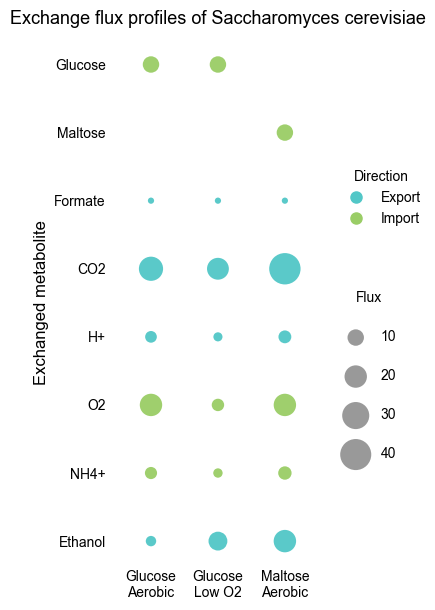

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

# ==============================
# 0. PDF 字体可编辑
# ==============================
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

# ==============================
# 1. 读取数据
# ==============================
df = pd.read_csv("./data/S_cerevisiae_exchange_flux_summary.csv")

# ==============================
# 2. 过滤：保留所有非0 exchange，但去掉不想展示的无机离子/水
# ==============================
exclude_patterns = [
    "EX_fe3_e",
    "EX_fe2_e",
    "EX_ca2_e",
    "EX_so4_e",
    "EX_k_e",
    "EX_mg2_e",
    "EX_pi_e",
    "EX_h2o_e",
    "EX_na1_e"
]

df_plot = df[~df["rxn_id"].isin(exclude_patterns)].copy()

# ==============================
# 3. 美化名称
# ==============================
rxn_name_map = {
    "EX_glc__D_e": "Glucose",
    "EX_malt_e": "Maltose",
    "EX_dextrin_e": "Dextrin",
    "EX_starch_e": "Starch",
    "EX_ac_e": "Acetate",
    "EX_lac__L_e": "L-Lactate",
    "EX_for_e": "Formate",
    "EX_co2_e": "CO2",
    "EX_h_e": "H+",
    "EX_o2_e": "O2",
    "EX_nh4_e": "NH4+",
    "EX_glyclt_e": "Glycolate",
    "EX_etoh_e": "Ethanol"
}

df_plot["Metabolite"] = df_plot["rxn_id"].map(rxn_name_map).fillna(df_plot["rxn_id"])

# ==============================
# 4. 条件顺序
# ==============================
condition_order = [
    "glucose_aerobic",
    "glucose_low_o2",
    "maltose_aerobic",
    "dextrin_aerobic",
    "starch_aerobic"
]

condition_name_map = {
    "glucose_aerobic": "Glucose\nAerobic",
    "glucose_low_o2": "Glucose\nLow O2",
    "maltose_aerobic": "Maltose\nAerobic",
    "dextrin_aerobic": "Dextrin\nAerobic",
    "starch_aerobic": "Starch\nAerobic"
}

df_plot["Condition"] = df_plot["condition"].map(condition_name_map)

# ==============================
# 5. 代谢物顺序：严格按 rxn_name_map 顺序，只保留当前数据存在的
# ==============================
metabolite_order = [
    m for m in rxn_name_map.values()
    if m in df_plot["Metabolite"].unique()
]

df_plot["Metabolite"] = pd.Categorical(
    df_plot["Metabolite"],
    categories=metabolite_order,
    ordered=True
)

# ==============================
# 6. 方向和气泡大小
# ==============================
df_plot["Direction"] = df_plot["flux"].apply(lambda x: "Import" if x < 0 else "Export")

df_plot["AbsFlux"] = df_plot["flux"].abs().clip(upper=50)

size_scale = 12
min_size = 20
df_plot["s"] = df_plot["AbsFlux"] * size_scale + min_size

# ==============================
# 7. 坐标映射
# ==============================
x_labels = [condition_name_map[c] for c in condition_order if c in df_plot["condition"].unique()]
x_map = {name: i for i, name in enumerate(x_labels)}
y_map = {name: i for i, name in enumerate(metabolite_order)}

df_plot["x"] = df_plot["Condition"].map(x_map)
df_plot["y"] = df_plot["Metabolite"].map(y_map)

df_plot = df_plot.dropna(subset=["x", "y"]).copy()

# ==============================
# 8. 配色
# ==============================
palette = {
    "Export": "#52C7C7",
    "Import": "#9ACD66"
}

# ==============================
# 9. 作图
# ==============================
fig, ax = plt.subplots(figsize=(4, 6.2))

for direction in ["Export", "Import"]:
    sub = df_plot[df_plot["Direction"] == direction]
    ax.scatter(
        sub["x"],
        sub["y"],
        s=sub["s"],
        c=palette[direction],
        alpha=0.95,
        edgecolors="none",
        linewidths=0,
        label=direction
    )

# ==============================
# 10. 坐标轴设置
# ==============================
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_xlim(-0.5, len(x_labels) - 0.5)

ax.set_yticks(range(len(metabolite_order)))
ax.set_yticklabels(metabolite_order, fontsize=10)
ax.tick_params(axis='both', length=0)
ax.set_xlim(-0.6, len(x_labels) - 0.4)

ax.invert_yaxis()
ax.set_xlabel("")
ax.set_ylabel("Exchanged metabolite", fontsize=12)
ax.set_title("Exchange flux profiles of Saccharomyces cerevisiae", fontsize=13, pad=12)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)
ax.set_facecolor("none")
fig.patch.set_alpha(0)

# ==============================
# 11. 图例
# ==============================
export_patch = mlines.Line2D([], [], color=palette["Export"], marker="o", linestyle="None",
                             markersize=8, label="Export")
import_patch = mlines.Line2D([], [], color=palette["Import"], marker="o", linestyle="None",
                             markersize=8, label="Import")

legend1 = ax.legend(
    handles=[export_patch, import_patch],
    title="Direction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.70),
    frameon=False
)
ax.add_artist(legend1)

legend_flux = [10, 20, 30, 40]
size_handles = [
    ax.scatter([], [], s=flux * size_scale + min_size, color="gray", alpha=0.8,
               edgecolors="none", linewidths=0)
    for flux in legend_flux
]

legend2 = ax.legend(
    handles=size_handles,
    labels=[str(x) for x in legend_flux],
    title="Flux",
    loc="center left",
    bbox_to_anchor=(1.02, 0.36),
    frameon=False,
    labelspacing=1.8
)

# ==============================
# 12. 输出
# ==============================
plt.tight_layout()
plt.savefig(
    "S_cerevisiae_exchange_bubbleplot.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

In [22]:
import pandas as pd

met_rows = []

for met in model.metabolites:
    met_rows.append({
        "metabolite_id": met.id,
        "metabolite_name": met.name,
        "compartment": met.compartment,
        "formula": getattr(met, "formula", None),
        "charge": getattr(met, "charge", None)
    })

met_df = pd.DataFrame(met_rows)

met_df.to_csv("./data/S_cerevisiae_metabolites.csv", index=False)

print("Saved: S_cerevisiae_metabolites.csv")
met_df.head()

Saved: S_cerevisiae_metabolites.csv


,metabolite_id,metabolite_name,compartment,formula,charge
0,2dr5p_c,2-Deoxy-D-ribose 5-phosphate,c,C5H9O7P,-2
1,2hb_c,2 Hydroxybutyrate C4H7O3,c,C4H7O3,-1
2,2hb_e,2 Hydroxybutyrate C4H7O3,e,C4H7O3,-1
3,2hhxdal_c,2 Hydroxy hexadecanal C16H32O2,c,C16H32O2,0
4,2hp6mbq_m,2 Hexaprenyl 6 methoxy 1 4 benzoquinone C37H54O3,m,C37H54O3,0


In [23]:
rxn_rows = []

for rxn in model.reactions:
    # subsystem（有些模型在 annotation 里）
    subsystem = None
    if hasattr(rxn, "subsystem"):
        subsystem = rxn.subsystem

    if not subsystem and hasattr(rxn, "annotation"):
        subsystem = rxn.annotation.get("subsystem", None)

    rxn_rows.append({
        "reaction_id": rxn.id,
        "reaction_name": rxn.name,
        "reaction_equation": rxn.reaction,
        "lower_bound": rxn.lower_bound,
        "upper_bound": rxn.upper_bound,
        "gene_reaction_rule": rxn.gene_reaction_rule,
        "subsystem": subsystem
    })

rxn_df = pd.DataFrame(rxn_rows)

rxn_df.to_csv("./data/S_cerevisiae_reactions.csv", index=False)

print("Saved: S_cerevisiae_reactions.csv")
rxn_df.head()

Saved: S_cerevisiae_reactions.csv


,reaction_id,reaction_name,reaction_equation,lower_bound,upper_bound,gene_reaction_rule,subsystem
0,CITtcp,Citrateisocitrate antiport into peroxisome,cit_c + icit_x <=> cit_x + icit_c,-999999.0,999999.0,,None
1,13BGH,Endo 1 3 beta glucan glucohydrase,13BDglcn_c + h2o_c --> glc__D_c,0.0,999999.0,YGR282C,None
2,13BGHe,Exo 1 3 beta glucan glucohydrase,13BDglcn_e + h2o_e --> glc__D_e,0.0,999999.0,YOR190W or YDR261C or YLR300W,None
3,13GS,1 3 beta glucan synthase,udpg_c --> 13BDglcn_c + h_c + udp_c,0.0,999999.0,((YCR034W and YGR032W) and YLR343W) or ((YCR03...,None
4,16GS,1 6 beta glucan synthase,udpg_c --> 16BDglcn_c + h_c + udp_c,0.0,999999.0,YPR159W or YGR143W,None


In [24]:
pathway_df = rxn_df[[
    "reaction_id",
    "reaction_name",
    "subsystem"
]].copy()

pathway_df.to_csv("./data/S_cerevisiae_reaction_pathways.csv", index=False)

print("Saved: S_cerevisiae_reaction_pathways.csv")

Saved: S_cerevisiae_reaction_pathways.csv


In [25]:
pathway_summary = (
    rxn_df
    .assign(subsystem=rxn_df["subsystem"].fillna("Unknown"))
    .groupby("subsystem", as_index=False)
    .agg(reaction_count=("reaction_id", "count"))
    .sort_values("reaction_count", ascending=False)
)

pathway_summary.to_csv("./data/S_cerevisiae_pathway_summary.csv", index=False)

print("Saved: S_cerevisiae_pathway_summary.csv")
pathway_summary.head(20)

Saved: S_cerevisiae_pathway_summary.csv


,subsystem,reaction_count
0,Unknown,1577


In [27]:
active_rows = []

for res in sc_results:
    cond = res["condition"]
    sol = res["solution"]["pfba_solution"]

    for rxn in model.reactions:
        flux = sol.fluxes[rxn.id]

        if abs(flux) > 1e-6:
            subsystem = None
            if hasattr(rxn, "subsystem"):
                subsystem = rxn.subsystem
            if not subsystem and hasattr(rxn, "annotation"):
                subsystem = rxn.annotation.get("subsystem", None)

            active_rows.append({
                "condition": cond,
                "reaction_id": rxn.id,
                "reaction_name": rxn.name,
                "flux": float(flux),
                "subsystem": subsystem,
                "equation": rxn.reaction
            })

active_df = pd.DataFrame(active_rows)

active_df.to_csv("./data/S_cerevisiae_active_reactions.csv", index=False)

print("Saved: S_cerevisiae_active_reactions.csv")
active_df.head()

Saved: S_cerevisiae_active_reactions.csv


,condition,reaction_id,reaction_name,flux,subsystem,equation
0,glucose_aerobic,13GS,1 3 beta glucan synthase,0.958322,None,udpg_c --> 13BDglcn_c + h_c + udp_c
1,glucose_aerobic,2DDA7Ptm,2 Dehydro 3 deoxy D arabino heptonate7 phohsph...,-0.223197,None,2dda7p_c <=> 2dda7p_m
2,glucose_aerobic,ACCOAC,Acetyl-CoA carboxylase,0.335767,None,accoa_c + atp_c + hco3_c <=> adp_c + h_c + mal...
3,glucose_aerobic,AGAT_SC,1 Acyl glycerol 3 phosphate acyltransferase y...,0.020859,None,0.01 1ag3p_SC_c + 0.02 dcacoa_c + 0.06 ddcacoa...
4,glucose_aerobic,AGPRim,N acetyl g glutamyl phosphate reductase irrev...,0.274795,None,acg5p_m + h_m + nadph_m --> acg5sa_m + nadp_m ...
